# Social Media Analytics — Master CRISP-DM Pipeline
**Organization:** Lighthouse PH  
**Pipeline:** `social_media_analytics`  

This notebook runs the full CRISP-DM pipeline end-to-end from raw CSV to evaluated model artifacts. It is self-contained and can be re-run at any time to regenerate all outputs.

| Phase | Section | Purpose |
|---|---|---|
| 1 | Business Understanding | Problem framing, success criteria |
| 2 | Data Understanding | Load and profile raw data |
| 3 | Data Preparation | Engineer features, cap outliers, split train/test |
| 4 | Modeling | CV model selection, fit final two-stage models |
| 5 | Evaluation | Test-set metrics, go/no-go, executive summary |

---

**Run the entire notebook top-to-bottom.** All artifacts are regenerated from the raw source CSV.

---
## Phase 1 — Business Understanding

### Problem Statement
Lighthouse PH publishes social media posts across multiple platforms to raise awareness and solicit donations for its resident community. The organisation wants to understand:

1. **What post characteristics drive donation value?** → Explanatory model (all features)
2. **How should a post be structured *before* publishing?** → Recommendation model (pre-publication features only)

### Why a Two-Stage Model?
The target (`estimated_donation_value_php`) is zero-inflated — many posts generate ₱0 in donations. A single regression would underfit on the large zero mass. The two-stage approach separates the problem:
- **Stage 1 (classifier):** Does this post generate *any* donation?
- **Stage 2 (regressor):** *How much* does it generate, given that it does?
- **Combined output:** P(has_donation) × expected value in PHP

### Feature Split
| Group | Features | Used in |
|---|---|---|
| Pre-publication | Platform, post type, timing, CTA, hashtags, caption length, content topic, resident story, engineered flags | Both models |
| Post-publication | Engagement metrics (shares, likes, reach, etc.) | Explanatory only |

### Success Criteria (Phase 1)
| Model | Stage 1 ROC AUC | Stage 2 R² |
|---|---|---|
| Explanatory | ≥ 0.70 | ≥ 0.35 |
| Recommendation | ≥ 0.65 | ≥ 0.35 |

---
## Phase 2 — Data Understanding

In [1]:
import sys, json
from pathlib import Path
from datetime import datetime, timezone

PIPELINE_ROOT = Path(".").resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score, train_test_split,
)

from src.config import (
    SOURCE_CSV, TARGET_VALUE, TARGET_BINARY, TARGET_LOG,
    DATA_PROCESSED, FEATURE_COLS_PATH,
    EXPLANATORY_MODEL_PATH, RECOMMENDATION_MODEL_PATH,
    RUNS_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR,
    PRE_PUB_FEATURES, POST_PUB_FEATURES,
    SEED, TEST_SIZE,
)
from src.data_io  import load_csv
from src.features import engineer_features, build_targets, get_feature_sets
from src.metrics  import baseline_classifier, report_two_stage
from src.modeling import (
    TwoStageModel, build_preprocessor,
    get_candidate_classifiers, get_candidate_regressors,
)
from src.evaluation import (
    plot_stage1_curves, plot_stage2_residuals,
    plot_platform_breakdown, plot_post_type_breakdown,
)

sns.set_style("whitegrid")
for d in (DATA_PROCESSED, MODELS_DIR, RUNS_DIR, FIGURES_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("All imports OK.")

All imports OK.


In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df_raw = load_csv()

print(f"Shape         : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Target range  : ₱{df_raw[TARGET_VALUE].min():,.2f} – ₱{df_raw[TARGET_VALUE].max():,.2f}")
print(f"Zero-value %  : {(df_raw[TARGET_VALUE] == 0).mean():.1%}")
print(f"Positive rate : {(df_raw[TARGET_VALUE] > 0).mean():.1%}")
print()
print("Platforms:")
print(df_raw["platform"].value_counts().to_string())
print()
print("Post types:")
print(df_raw["post_type"].value_counts().to_string())

Shape         : 812 rows × 39 columns
Target range  : ₱0.00 – ₱2,402,435.96
Zero-value %  : 35.7%
Positive rate : 64.3%

Platforms:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71

Post types:
post_type
ImpactStory           203
Campaign              156
EventPromotion        131
ThankYou              118
EducationalContent    114
FundraisingAppeal      90


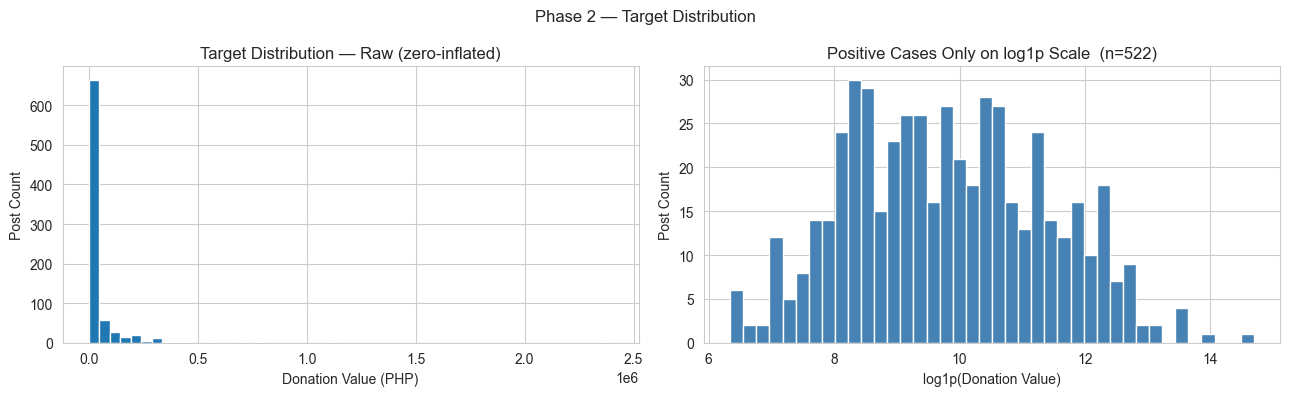

Columns with missing values:
subscriber_count_at_post     91.256158
avg_view_duration_seconds    91.256158
watch_time_seconds           91.256158
forwards                     88.546798
boost_budget_php             84.359606
campaign_name                71.428571
video_views                  58.990148
call_to_action_type          39.285714
hashtags                     18.226601


In [3]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_raw[TARGET_VALUE], bins=50, edgecolor="white")
axes[0].set_xlabel("Donation Value (PHP)")
axes[0].set_ylabel("Post Count")
axes[0].set_title("Target Distribution — Raw (zero-inflated)")

pos_vals = df_raw[df_raw[TARGET_VALUE] > 0][TARGET_VALUE]
axes[1].hist(np.log1p(pos_vals), bins=40, edgecolor="white", color="steelblue")
axes[1].set_xlabel("log1p(Donation Value)")
axes[1].set_ylabel("Post Count")
axes[1].set_title(f"Positive Cases Only on log1p Scale  (n={len(pos_vals):,})")

plt.suptitle("Phase 2 — Target Distribution", fontsize=12)
plt.tight_layout()
plt.show()

# Missingness summary
miss = df_raw.isnull().mean().mul(100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print("Columns with missing values:")
print(miss_nonzero.to_string() if len(miss_nonzero) else "  None")

---
## Phase 3 — Data Preparation

1. Engineer derived features (`is_peak_hour`, `is_peak_day`, `has_video_content`, `is_impact_or_fundraising`, `engagement_per_follower`)
2. Build binary and log targets
3. Apply p99 cap to the target (computed on train only, applied to both splits)
4. Stratified train/test split (80/20, stratified on `has_donation`)
5. Save processed splits and feature metadata

In [4]:
# -- Engineer features and targets ------------------------------------------
df = engineer_features(df_raw)
df = build_targets(df)

pre_pub, post_pub = get_feature_sets(df)
all_features = list(dict.fromkeys(pre_pub + post_pub))   # preserve order, no dupes

# -- Drop rows missing the target only; imputer handles feature NaNs ----------
# Do NOT drop on all_features: engagement_per_follower is NaN when
# follower_count_at_post=0, silently discarding ~95% of rows.
target_cols = [TARGET_BINARY, TARGET_LOG, TARGET_VALUE]
df_model    = df.dropna(subset=target_cols).reset_index(drop=True)
print(f"After dropna: {len(df_model):,} rows  (dropped {len(df) - len(df_model)} rows)")

# -- Stratified split ---------------------------------------------------------
train_idx, test_idx = train_test_split(
    df_model.index, test_size=TEST_SIZE, random_state=SEED,
    stratify=df_model[TARGET_BINARY],
)
df_train = df_model.loc[train_idx].reset_index(drop=True)
df_test  = df_model.loc[test_idx].reset_index(drop=True)

# -- p99 cap: computed on train only, applied to both -------------------------
p99_cap = df_train[TARGET_VALUE].quantile(0.99)
for split in (df_train, df_test):
    split[TARGET_VALUE] = split[TARGET_VALUE].clip(upper=p99_cap)
    split[TARGET_LOG]   = np.log1p(split[TARGET_VALUE].clip(lower=0))

print(f"Train         : {len(df_train):,} rows  |  Test: {len(df_test):,} rows")
print(f"Positive rate : {df_train[TARGET_BINARY].mean():.1%} (train)  "
      f"{df_test[TARGET_BINARY].mean():.1%} (test)")
print(f"p99 cap       : ₱{p99_cap:,.2f}")

# -- Numeric / categorical split for preprocessor ----------------------------
numeric_expl      = df_train[all_features].select_dtypes(include='number').columns.tolist()
categorical_expl  = df_train[all_features].select_dtypes(exclude='number').columns.tolist()
numeric_rec       = df_train[pre_pub].select_dtypes(include='number').columns.tolist()
categorical_rec   = df_train[pre_pub].select_dtypes(exclude='number').columns.tolist()

# -- Save processed splits + feature metadata ---------------------------------
df_train.to_csv(DATA_PROCESSED / 'train.csv', index=False)
df_test.to_csv(DATA_PROCESSED  / 'test.csv',  index=False)

feature_meta = {
    'explanatory':      all_features,
    'recommendation':   pre_pub,
    'numeric_expl':     numeric_expl,
    'categorical_expl': categorical_expl,
    'numeric_rec':      numeric_rec,
    'categorical_rec':  categorical_rec,
    'p99_cap':          p99_cap,
}
with open(FEATURE_COLS_PATH, 'w') as f:
    json.dump(feature_meta, f, indent=2)

print(f"Train CSV saved ({len(df_train):,} rows) -> {DATA_PROCESSED / 'train.csv'}")
print(f"Test  CSV saved ({len(df_test):,} rows)  -> {DATA_PROCESSED / 'test.csv'}")
print(f"Feature meta saved -> {FEATURE_COLS_PATH}")

After dropna: 812 rows  (dropped 0 rows)
Train         : 649 rows  |  Test: 163 rows
Positive rate : 64.3% (train)  64.4% (test)
p99 cap       : ₱353,729.39
Train CSV saved (649 rows) -> C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\data\processed\train.csv
Test  CSV saved (163 rows)  -> C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\data\processed\test.csv
Feature meta saved -> C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\data\processed\feature_cols.json


---
## Phase 4 — Modeling

**Two models, two stages each:**
- Cross-validate candidate classifiers (Logistic Regression vs Random Forest) with 5-fold stratified CV
- Cross-validate candidate regressors (Ridge vs Random Forest) on positive cases with 5-fold KFold CV
- Select best by CV score, fit on full training set
- Save artifacts

> The test set is **not touched** during this phase.

In [5]:
# ── Feature matrices ──────────────────────────────────────────────────────────
X_train     = df_train[all_features]
X_train_rec = df_train[pre_pub]
y_train_bin = df_train[TARGET_BINARY]
y_train_log = df_train[TARGET_LOG]

pos_mask_train  = y_train_bin.values == 1
X_train_pos     = X_train[pos_mask_train]
X_train_rec_pos = X_train_rec[pos_mask_train]
y_train_log_pos = y_train_log.values[pos_mask_train]


def run_cv_classifiers(X, y, label):
    prep      = build_preprocessor(
        X.select_dtypes(include="number").columns.tolist(),
        X.select_dtypes(exclude="number").columns.tolist(),
    )
    candidates = get_candidate_classifiers(prep)
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    results    = {}
    for name, pipe in candidates.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        results[name] = {"mean": scores.mean(), "std": scores.std()}
    best = max(results, key=lambda k: results[k]["mean"])
    return results, best, candidates[best]


def run_cv_regressors(X_pos, y_pos, label):
    prep      = build_preprocessor(
        X_pos.select_dtypes(include="number").columns.tolist(),
        X_pos.select_dtypes(exclude="number").columns.tolist(),
    )
    candidates = get_candidate_regressors(prep)
    cv         = KFold(n_splits=5, shuffle=True, random_state=SEED)
    results    = {}
    for name, pipe in candidates.items():
        scores = cross_val_score(pipe, X_pos, y_pos, cv=cv, scoring="r2", n_jobs=-1)
        results[name] = {"mean": scores.mean(), "std": scores.std()}
    best = max(results, key=lambda k: results[k]["mean"])
    return results, best, candidates[best]


print("=" * 58)
print("EXPLANATORY MODEL (all features)")
print("=" * 58)
clf_res, best_clf, best_clf_pipe = run_cv_classifiers(X_train, y_train_bin, "Explanatory")
for name, r in clf_res.items():
    mark = " ◄" if name == best_clf else ""
    print(f"  Stage 1 {name:20s}  ROC AUC {r['mean']:.4f} ± {r['std']:.4f}{mark}")

reg_res, best_reg, best_reg_pipe = run_cv_regressors(X_train_pos, y_train_log_pos, "Explanatory")
for name, r in reg_res.items():
    mark = " ◄" if name == best_reg else ""
    print(f"  Stage 2 {name:20s}  R²      {r['mean']:.4f} ± {r['std']:.4f}{mark}")

print()
print("=" * 58)
print("RECOMMENDATION MODEL (pre-pub features only)")
print("=" * 58)
clf_res_r, best_clf_r, best_clf_r_pipe = run_cv_classifiers(X_train_rec, y_train_bin, "Recommendation")
for name, r in clf_res_r.items():
    mark = " ◄" if name == best_clf_r else ""
    print(f"  Stage 1 {name:20s}  ROC AUC {r['mean']:.4f} ± {r['std']:.4f}{mark}")

reg_res_r, best_reg_r, best_reg_r_pipe = run_cv_regressors(X_train_rec_pos, y_train_log_pos, "Recommendation")
for name, r in reg_res_r.items():
    mark = " ◄" if name == best_reg_r else ""
    print(f"  Stage 2 {name:20s}  R²      {r['mean']:.4f} ± {r['std']:.4f}{mark}")

EXPLANATORY MODEL (all features)
  Stage 1 LogReg                ROC AUC 0.9737 ± 0.0114
  Stage 1 RandomForest          ROC AUC 0.9764 ± 0.0125 ◄
  Stage 2 Ridge                 R²      0.6127 ± 0.0986
  Stage 2 RandomForest          R²      0.6832 ± 0.0445 ◄

RECOMMENDATION MODEL (pre-pub features only)
  Stage 1 LogReg                ROC AUC 0.8976 ± 0.0359 ◄
  Stage 1 RandomForest          ROC AUC 0.8969 ± 0.0279
  Stage 2 Ridge                 R²      0.4424 ± 0.0764 ◄
  Stage 2 RandomForest          R²      0.3810 ± 0.0209


In [6]:
# ── Fit final models on full training set ─────────────────────────────────────
expl_model = TwoStageModel(
    classifier=clone(best_clf_pipe),
    regressor =clone(best_reg_pipe),
)
expl_model.fit(X_train, y_train_bin, y_train_log)
print("Explanatory model fitted.")

rec_model = TwoStageModel(
    classifier=clone(best_clf_r_pipe),
    regressor =clone(best_reg_r_pipe),
)
rec_model.fit(X_train_rec, y_train_bin, y_train_log)
print("Recommendation model fitted.")

# ── Save artifacts ────────────────────────────────────────────────────────────
joblib.dump({"model": expl_model, "feature_cols": all_features}, EXPLANATORY_MODEL_PATH)
joblib.dump({"model": rec_model,  "feature_cols": pre_pub},      RECOMMENDATION_MODEL_PATH)
print(f"\nSaved → {EXPLANATORY_MODEL_PATH}")
print(f"Saved → {RECOMMENDATION_MODEL_PATH}")

Explanatory model fitted.
Recommendation model fitted.

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\artifacts\models\explanatory_model.joblib
Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\artifacts\models\recommendation_model.joblib


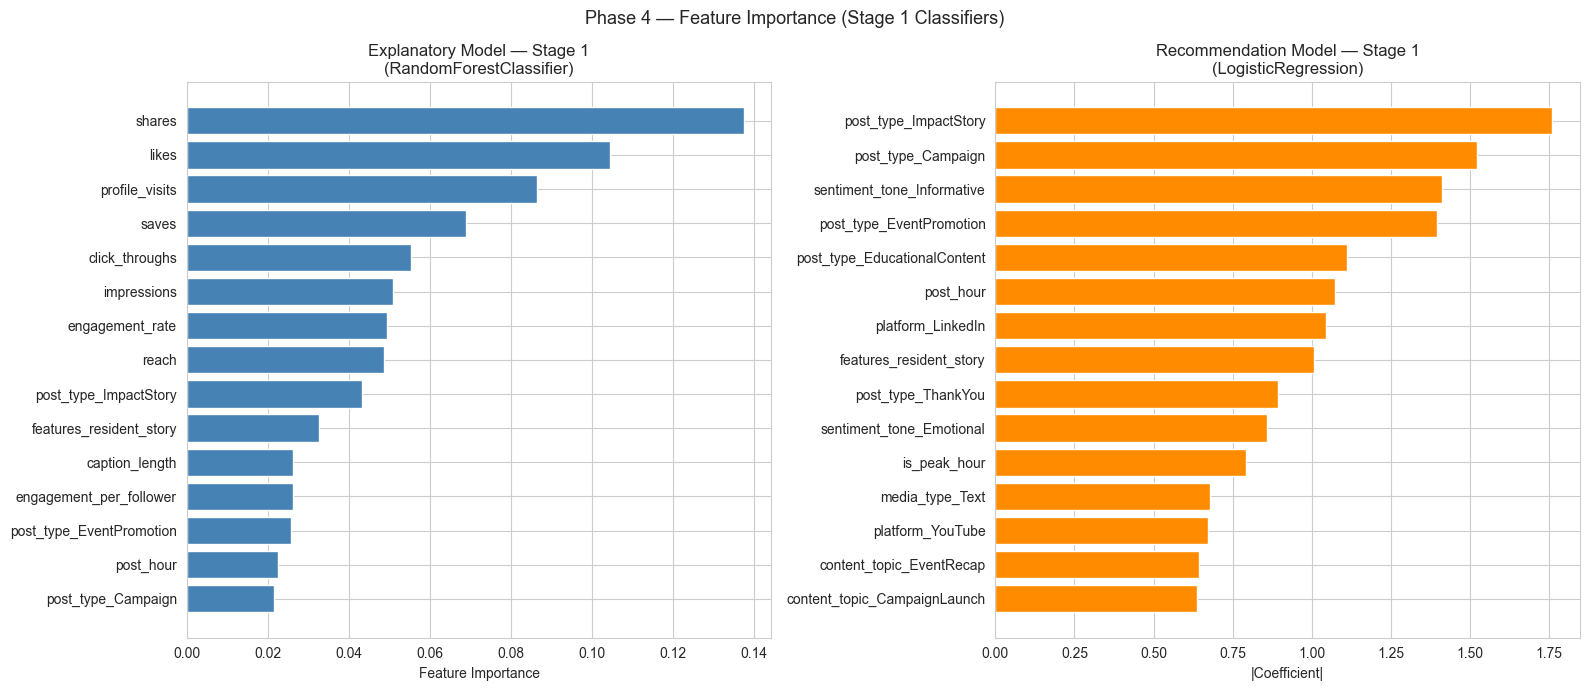

In [7]:
# ── Feature importance — top 15 per model ────────────────────────────────────
def get_expanded_names(pipeline_step):
    prep = pipeline_step.named_steps["prep"]
    return [n.split("__", 1)[-1] for n in prep.get_feature_names_out()]


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
TOP_N = 15

# Explanatory — RF classifier (feature_importances_)
expl_clf_step = expl_model.classifier.named_steps["model"]
if hasattr(expl_clf_step, "feature_importances_"):
    names = get_expanded_names(expl_model.classifier)
    imp   = expl_clf_step.feature_importances_
    idx   = np.argsort(imp)[-TOP_N:]
    axes[0].barh([names[i] for i in idx], imp[idx], color="steelblue")
    axes[0].set_xlabel("Feature Importance")
    axes[0].set_title(f"Explanatory Model — Stage 1\n({type(expl_clf_step).__name__})")

# Recommendation — LogReg |coef|
rec_clf_step = rec_model.classifier.named_steps["model"]
names_rec = get_expanded_names(rec_model.classifier)
if hasattr(rec_clf_step, "coef_"):
    coef = np.abs(rec_clf_step.coef_[0])
    idx  = np.argsort(coef)[-TOP_N:]
    axes[1].barh([names_rec[i] for i in idx], coef[idx], color="darkorange")
    axes[1].set_xlabel("|Coefficient|")
    axes[1].set_title(f"Recommendation Model — Stage 1\n({type(rec_clf_step).__name__})")
elif hasattr(rec_clf_step, "feature_importances_"):
    imp  = rec_clf_step.feature_importances_
    idx  = np.argsort(imp)[-TOP_N:]
    axes[1].barh([names_rec[i] for i in idx], imp[idx], color="darkorange")
    axes[1].set_xlabel("Feature Importance")
    axes[1].set_title(f"Recommendation Model — Stage 1\n({type(rec_clf_step).__name__})")

plt.suptitle("Phase 4 — Feature Importance (Stage 1 Classifiers)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "master_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 5 — Evaluation

The frozen test set is used here for the first and only time.

In [8]:
# ── Test set feature matrices ──────────────────────────────────────────────────
X_test     = df_test[all_features]
X_test_rec = df_test[pre_pub]
y_test_bin = df_test[TARGET_BINARY]
y_test_log = df_test[TARGET_LOG]
y_test_val = df_test[TARGET_VALUE]

pos_mask_test   = y_test_bin.values == 1
X_test_pos      = X_test[pos_mask_test]
X_test_rec_pos  = X_test_rec[pos_mask_test]
y_test_log_pos  = y_test_log.values[pos_mask_test]

# ── Predictions ───────────────────────────────────────────────────────────────
y_proba_expl    = expl_model.predict_proba_stage1(X_test)
y_pred_bin_expl = expl_model.predict_stage1(X_test)
y_pred_log_expl = expl_model.predict_stage2(X_test_pos)

y_proba_rec     = rec_model.predict_proba_stage1(X_test_rec)
y_pred_bin_rec  = rec_model.predict_stage1(X_test_rec)
y_pred_log_rec  = rec_model.predict_stage2(X_test_rec_pos)

print(f"Test set: {len(y_test_bin):,} posts  |  "
      f"Positive: {pos_mask_test.sum()} ({pos_mask_test.mean():.1%})")

Test set: 163 posts  |  Positive: 105 (64.4%)


In [9]:
# ── Compute all test metrics ──────────────────────────────────────────────────
auc_expl = roc_auc_score(y_test_bin, y_proba_expl)
auc_rec  = roc_auc_score(y_test_bin, y_proba_rec)
r2_expl  = r2_score(y_test_log_pos, y_pred_log_expl)
r2_rec   = r2_score(y_test_log_pos, y_pred_log_rec)

rmse_php_expl = np.sqrt(mean_squared_error(
    np.expm1(y_test_log_pos), np.expm1(y_pred_log_expl)
))
rmse_php_rec  = np.sqrt(mean_squared_error(
    np.expm1(y_test_log_pos), np.expm1(y_pred_log_rec)
))

# Baselines
majority_acc   = baseline_classifier(y_test_bin)
mean_log_train = y_train_log.values[pos_mask_train].mean()
baseline_rmse  = np.sqrt(mean_squared_error(
    np.expm1(y_test_log_pos),
    np.full_like(y_test_log_pos, np.expm1(mean_log_train))
))

print("── Stage 1 ─────────────────────────────────────────────────────")
print(f"  Majority-class baseline accuracy : {majority_acc:.4f}")
print(f"  Random baseline ROC AUC          : 0.5000")
print(f"  Explanatory  ROC AUC             : {auc_expl:.4f}  ({'✓ GO' if auc_expl >= 0.70 else '✗ NO-GO'}, threshold ≥ 0.70)")
print(f"  Recommendation ROC AUC           : {auc_rec:.4f}  ({'✓ GO' if auc_rec >= 0.65 else '✗ NO-GO'}, threshold ≥ 0.65)")
print()
print("── Stage 2 ─────────────────────────────────────────────────────")
print(f"  Mean-predict baseline RMSE (PHP) : ₱{baseline_rmse:,.2f}")
print(f"  Explanatory  R²                  : {r2_expl:.4f}  ({'✓ GO' if r2_expl >= 0.35 else '✗ NO-GO'}, threshold ≥ 0.35)")
print(f"  Explanatory  RMSE (PHP)          : ₱{rmse_php_expl:,.2f}")
print(f"  Recommendation R²                : {r2_rec:.4f}  ({'✓ GO' if r2_rec >= 0.35 else '✗ NO-GO'}, threshold ≥ 0.35)")
print(f"  Recommendation RMSE (PHP)        : ₱{rmse_php_rec:,.2f}")

── Stage 1 ─────────────────────────────────────────────────────
  Majority-class baseline accuracy : 0.6442
  Random baseline ROC AUC          : 0.5000
  Explanatory  ROC AUC             : 0.9843  (✓ GO, threshold ≥ 0.70)
  Recommendation ROC AUC           : 0.8852  (✓ GO, threshold ≥ 0.65)

── Stage 2 ─────────────────────────────────────────────────────
  Mean-predict baseline RMSE (PHP) : ₱91,474.49
  Explanatory  R²                  : 0.7680  (✓ GO, threshold ≥ 0.35)
  Explanatory  RMSE (PHP)          : ₱53,923.44
  Recommendation R²                : 0.5152  (✓ GO, threshold ≥ 0.35)
  Recommendation RMSE (PHP)        : ₱75,026.89


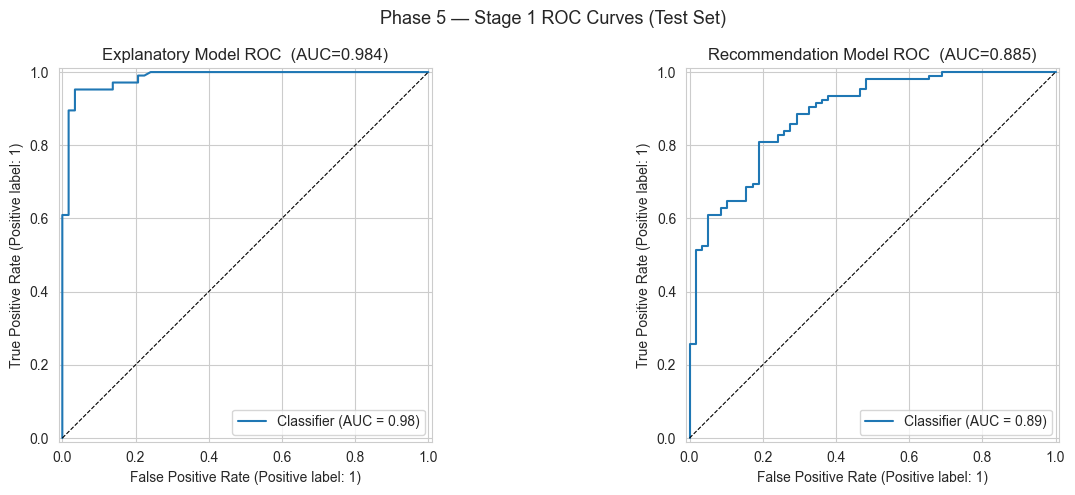

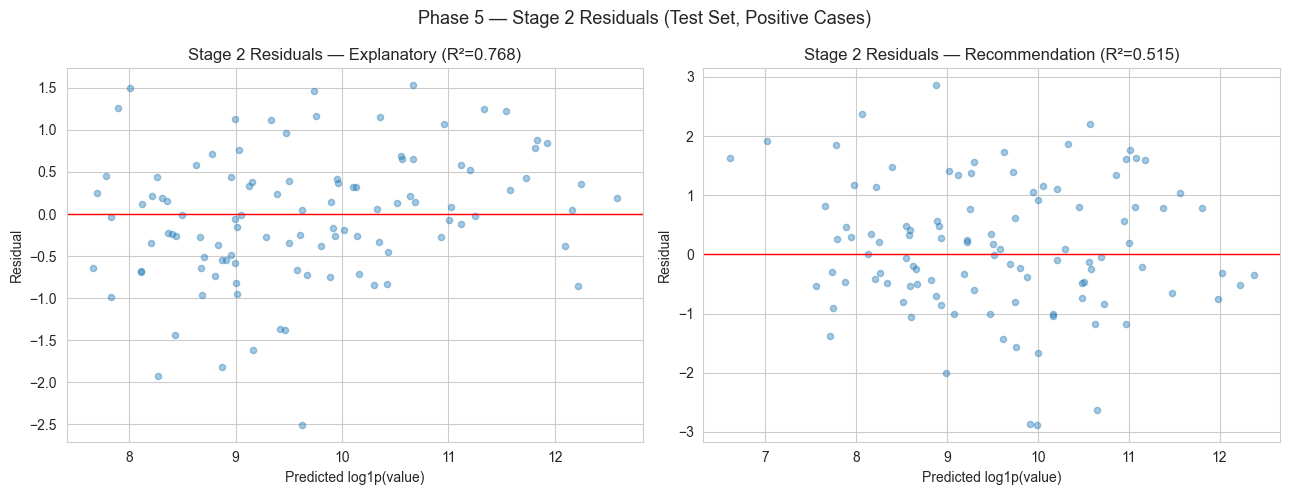

In [10]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test_bin, y_proba_expl, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_title(f"Explanatory Model ROC  (AUC={auc_expl:.3f})")

RocCurveDisplay.from_predictions(y_test_bin, y_proba_rec, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title(f"Recommendation Model ROC  (AUC={auc_rec:.3f})")

plt.suptitle("Phase 5 — Stage 1 ROC Curves (Test Set)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "master_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Residual plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, label in [
    (axes[0], y_pred_log_expl, f"Explanatory (R²={r2_expl:.3f})"),
    (axes[1], y_pred_log_rec,  f"Recommendation (R²={r2_rec:.3f})"),
]:
    residuals = y_test_log_pos - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=20)
    ax.axhline(0, color="red", lw=1)
    ax.set_xlabel("Predicted log1p(value)")
    ax.set_ylabel("Residual")
    ax.set_title(f"Stage 2 Residuals — {label}")

plt.suptitle("Phase 5 — Stage 2 Residuals (Test Set, Positive Cases)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "master_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── Go / No-Go decision table ─────────────────────────────────────────────────
criteria = [
    ("Explanatory   Stage 1 ROC AUC", auc_expl, 0.70),
    ("Explanatory   Stage 2 R²",      r2_expl,  0.35),
    ("Recommendation Stage 1 ROC AUC", auc_rec, 0.65),
    ("Recommendation Stage 2 R²",      r2_rec,  0.35),
]

all_go = all(v >= t for _, v, t in criteria)

print("═" * 70)
print("GO / NO-GO DECISION")
print("═" * 70)
print(f"  {'Criterion':<40} {'Threshold':<12} Result")
print("-" * 70)
for label, value, threshold in criteria:
    verdict = "✓ GO" if value >= threshold else "✗ NO-GO"
    print(f"  {label:<40} ≥ {threshold:<10}  {verdict}  ({value:.4f})")
print("-" * 70)
overall = "✓ BOTH ARTIFACTS APPROVED" if all_go else "✗ REVIEW REQUIRED"
print(f"  OVERALL: {overall}")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
GO / NO-GO DECISION
══════════════════════════════════════════════════════════════════════
  Criterion                                Threshold    Result
----------------------------------------------------------------------
  Explanatory   Stage 1 ROC AUC            ≥ 0.7         ✓ GO  (0.9843)
  Explanatory   Stage 2 R²                 ≥ 0.35        ✓ GO  (0.7680)
  Recommendation Stage 1 ROC AUC           ≥ 0.65        ✓ GO  (0.8852)
  Recommendation Stage 2 R²                ≥ 0.35        ✓ GO  (0.5152)
----------------------------------------------------------------------
  OVERALL: ✓ BOTH ARTIFACTS APPROVED
══════════════════════════════════════════════════════════════════════


In [12]:
# ── Save run metadata ─────────────────────────────────────────────────────────
run_meta = {
    "trained_at"        : datetime.now(timezone.utc).isoformat(),
    "n_train"           : int(len(df_train)),
    "n_test"            : int(len(df_test)),
    "p99_cap_php"       : p99_cap,
    "explanatory": {
        "classifier"       : best_clf,
        "regressor"        : best_reg,
        "cv_stage1_roc_auc": round(clf_res[best_clf]["mean"], 4),
        "cv_stage2_r2"     : round(reg_res[best_reg]["mean"], 4),
        "test_stage1_auc"  : round(auc_expl, 4),
        "test_stage2_r2"   : round(r2_expl,  4),
        "test_stage2_rmse_php": round(rmse_php_expl, 2),
        "n_features"       : len(all_features),
        "go"               : bool(auc_expl >= 0.70 and r2_expl >= 0.35),
    },
    "recommendation": {
        "classifier"       : best_clf_r,
        "regressor"        : best_reg_r,
        "cv_stage1_roc_auc": round(clf_res_r[best_clf_r]["mean"], 4),
        "cv_stage2_r2"     : round(reg_res_r[best_reg_r]["mean"], 4),
        "test_stage1_auc"  : round(auc_rec,  4),
        "test_stage2_r2"   : round(r2_rec,   4),
        "test_stage2_rmse_php": round(rmse_php_rec, 2),
        "n_features"       : len(pre_pub),
        "go"               : bool(auc_rec >= 0.65 and r2_rec >= 0.35),
    },
}
with open(RUNS_DIR / "latest_run.json", "w") as f:
    json.dump(run_meta, f, indent=2)
print(f"Saved → {RUNS_DIR / 'latest_run.json'}")
print(json.dumps(run_meta, indent=2))

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\artifacts\runs\latest_run.json
{
  "trained_at": "2026-04-09T04:49:39.253532+00:00",
  "n_train": 649,
  "n_test": 163,
  "p99_cap_php": 353729.38719999924,
  "explanatory": {
    "classifier": "RandomForest",
    "regressor": "RandomForest",
    "cv_stage1_roc_auc": 0.9764,
    "cv_stage2_r2": 0.6832,
    "test_stage1_auc": 0.9843,
    "test_stage2_r2": 0.768,
    "test_stage2_rmse_php": 53923.44,
    "n_features": 28,
    "go": true
  },
  "recommendation": {
    "classifier": "LogReg",
    "regressor": "Ridge",
    "cv_stage1_roc_auc": 0.8976,
    "cv_stage2_r2": 0.4424,
    "test_stage1_auc": 0.8852,
    "test_stage2_r2": 0.5152,
    "test_stage2_rmse_php": 75026.89,
    "n_features": 17,
    "go": true
  }
}


In [13]:
# ── Executive summary ─────────────────────────────────────────────────────────
summary_path = REPORTS_DIR / "executive_summary.md"

expl_s1 = f"AUC {auc_expl:.3f} — {'GO' if auc_expl >= 0.70 else 'NO-GO'} (≥ 0.70)"
expl_s2 = f"R² {r2_expl:.3f}, RMSE ₱{rmse_php_expl:,.0f} — {'GO' if r2_expl >= 0.35 else 'NO-GO'} (≥ 0.35)"
rec_s1  = f"AUC {auc_rec:.3f}  — {'GO' if auc_rec >= 0.65 else 'NO-GO'} (≥ 0.65)"
rec_s2  = f"R² {r2_rec:.3f},  RMSE ₱{rmse_php_rec:,.0f}  — {'GO' if r2_rec >= 0.35 else 'NO-GO'} (≥ 0.35)"
verdict = "APPROVED FOR DEPLOYMENT" if all_go else "REVIEW REQUIRED"

summary_text = f"""# Executive Summary — Social Media Analytics Pipeline
**Organization:** Lighthouse PH  
**Trained:** {run_meta['trained_at'][:10]}  
**Source:** master_crispdm_pipeline.ipynb  

---

## Purpose

Lighthouse PH publishes social media posts across multiple platforms to raise awareness and solicit donations. This pipeline answers two questions:

1. **What post characteristics drive donation value?** (explanatory model — all features)
2. **How should a post be structured before publishing to maximise donation probability?** (recommendation model — pre-publication features only)

---

## Data

- **Posts:** {run_meta['n_train'] + run_meta['n_test']:,} total  
- **Training:** {run_meta['n_train']:,} | **Test:** {run_meta['n_test']:,} (stratified, frozen)  
- **Target:** `estimated_donation_value_php` — zero-inflated  
- **p99 cap:** ₱{run_meta['p99_cap_php']:,.2f}

---

## Results

| Artifact | Stage | Metric | Result |
|---|---|---|---|
| Explanatory | Stage 1 (classifier) | ROC AUC | {expl_s1} |
| Explanatory | Stage 2 (regressor) | R² / RMSE | {expl_s2} |
| Recommendation | Stage 1 (classifier) | ROC AUC | {rec_s1} |
| Recommendation | Stage 2 (regressor) | R² / RMSE | {rec_s2} |

**Overall: {verdict}**

---

## Key Findings

**What drives donation value (post-publication):** Shares, likes, profile visits, saves, and click-throughs are the strongest predictors. High-engagement posts drive fundraising — track these metrics on the dashboard.

**What to optimise before publishing:**
1. Use the **ImpactStory** post type for fundraising campaigns
2. Feature a **resident's personal story** — statistically more likely to generate donations
3. Include a clear **donation call to action**
4. Post on **Monday or Tuesday, 9–11 AM or 6–7 PM**
5. Use **Impact or Fundraising** content topics

---

## Artifacts

| File | Purpose |
|---|---|
| `artifacts/models/explanatory_model.joblib` | Analytics dashboard scoring |
| `artifacts/models/recommendation_model.joblib` | Post optimizer widget (API) |
| `data/processed/train.csv` / `test.csv` | Frozen splits |
| `artifacts/runs/latest_run.json` | Run metadata |

---

## Monitoring

Retrain when ≥ 50 new posts are accumulated or a new platform/post type appears.  
Run inference: `python -m jobs.run_inference --source supabase --sink supabase`

*Generated by `notebooks/master_crispdm_pipeline.ipynb`*
"""

summary_path.write_text(summary_text, encoding="utf-8")
print(f"Executive summary written → {summary_path}")

Executive summary written → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\executive_summary.md


---
## Pipeline Summary

| Artifact | Location |
|---|---|
| Training split | `data/processed/train.csv` |
| Test split | `data/processed/test.csv` |
| Feature metadata | `data/processed/feature_cols.json` |
| Explanatory model | `artifacts/models/explanatory_model.joblib` |
| Recommendation model | `artifacts/models/recommendation_model.joblib` |
| Run metadata | `artifacts/runs/latest_run.json` |
| Figures | `reports/figures/` |
| Executive summary | `reports/executive_summary.md` |

**Next steps:**
- `python -m jobs.run_inference --source csv --sink csv` — score all posts
- `python -m jobs.run_inference --source supabase --sink supabase` — production inference
- FastAPI scoring endpoint (`api/score_post.py`) — powers the React post optimizer widget